**CSC4093/DSC4213: Deep Learning (2024/25)**

**Programming Assignment 02: Convolutional Networks and Transfer Learning**

In [6]:
import os
from google.colab import drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
PROJECT_BASE_PATH = '/content/drive/MyDrive/leaf_dataset'

In [9]:
import shutil
PROCESSED_PATH = '/content/drive/MyDrive/leaf_dataset/processed'
shutil.rmtree(PROCESSED_PATH)
print("Deleted old processed data")

Deleted old processed data


Splitting

In [10]:
import os
import shutil
import random

# Define paths

RAW_DATA_PATH = '/content/drive/MyDrive/leaf_dataset/leaf_dataset'
PROCESSED_PATH = '/content/drive/MyDrive/leaf_dataset/processed'

classes = ["brown_blight", "algal_leaf", "white_spot"]

if os.path.exists(PROCESSED_PATH):
    print("Dataset already processed. Skipping split.")
else:
    # Create the directory structure
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(PROCESSED_PATH, split, cls), exist_ok=True)

    # Split and Copy files
    for cls in classes:
        src_path = os.path.join(RAW_DATA_PATH, cls)
        images = [f for f in os.listdir(src_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

        random.seed(42)
        random.shuffle(images)

        train_idx = int(0.7 * len(images))
        val_idx = int(0.85 * len(images))

        train_files = images[:train_idx]
        val_files = images[train_idx:val_idx]
        test_files = images[val_idx:]

        def copy_files(files, split_name):
            for f in files:
                shutil.copy(os.path.join(src_path, f),
                            os.path.join(PROCESSED_PATH, split_name, cls, f))

        copy_files(train_files, 'train')
        copy_files(val_files, 'val')
        copy_files(test_files, 'test')

    print("Directory structure created and files split!")

Directory structure created and files split!


In [11]:
# 🔹 Check for duplicate files across splits

def check_leakage(base_path, classes):
    train_files = set()
    val_files = set()
    test_files = set()

    for cls in classes:
        train_files.update(os.listdir(os.path.join(base_path, 'train', cls)))
        val_files.update(os.listdir(os.path.join(base_path, 'val', cls)))
        test_files.update(os.listdir(os.path.join(base_path, 'test', cls)))

    print("Train-Val overlap:", len(train_files & val_files))
    print("Train-Test overlap:", len(train_files & test_files))
    print("Val-Test overlap:", len(val_files & test_files))

check_leakage(PROCESSED_PATH, classes)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [12]:
for cls in classes:
    raw_src = os.path.join(RAW_DATA_PATH, cls)
    if os.path.exists(raw_src):
        count = len([f for f in os.listdir(raw_src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Original {cls}: {count} images")

Original brown_blight: 113 images
Original algal_leaf: 113 images
Original white_spot: 142 images


Count Files

In [13]:
def count_files_in_splits(base_path, split_names, class_names):
    print(f"{'Split':<10} | {'Class':<15} | {'Count':<6}")
    print("-" * 35)

    total_files = 0
    for split in split_names:
        split_total = 0
        for cls in class_names:
            folder_path = os.path.join(base_path, split, cls)
            if os.path.exists(folder_path):
                # Count files that are actually in the folder
                num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
                print(f"{split:<10} | {cls:<15} | {num_files:<6}")
                split_total += num_files
                total_files += num_files
        print(f"{'':<10} | {'SUBTOTAL':<15} | {split_total:<6}")
        print("-" * 35)

    print(f"{'TOTAL':<28} | {total_files:<6}")

# Execute the count
count_files_in_splits(PROCESSED_PATH, ['train', 'val', 'test'], classes)

Split      | Class           | Count 
-----------------------------------
train      | brown_blight    | 79    
train      | algal_leaf      | 79    
train      | white_spot      | 99    
           | SUBTOTAL        | 257   
-----------------------------------
val        | brown_blight    | 17    
val        | algal_leaf      | 17    
val        | white_spot      | 21    
           | SUBTOTAL        | 55    
-----------------------------------
test       | brown_blight    | 17    
test       | algal_leaf      | 17    
test       | white_spot      | 22    
           | SUBTOTAL        | 56    
-----------------------------------
TOTAL                        | 368   


PREPROCESSING (Transforms)

Resize(224) → required for VGG/ResNet

RandomFlip + Rotation → data augmentation

Normalize → matches pretrained models

In [14]:
from torchvision import transforms

IMG_SIZE = 224

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation & Test transforms (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

LOAD DATASET

In [15]:
from torchvision import datasets
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_data = datasets.ImageFolder(PROCESSED_PATH + '/train', transform=train_transform)
val_data = datasets.ImageFolder(PROCESSED_PATH + '/val', transform=val_test_transform)
test_data = datasets.ImageFolder(PROCESSED_PATH + '/test', transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

CHECK CLASS LABELS


In [16]:

print("Class names:", train_data.classes)

Class names: ['algal_leaf', 'brown_blight', 'white_spot']


In [17]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels:", labels)

print(train_data.class_to_idx)

Image batch shape: torch.Size([16, 3, 224, 224])
Labels: tensor([0, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 1, 2])
{'algal_leaf': 0, 'brown_blight': 1, 'white_spot': 2}


Visualize Images

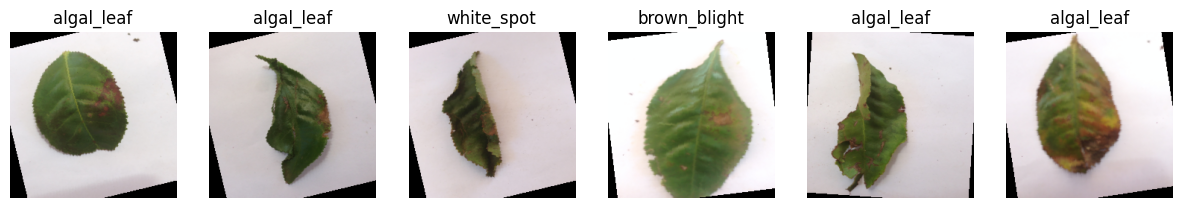

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(images, labels):
    images = images.numpy().transpose((0, 2, 3, 1))

    # Unnormalize
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    images = std * images + mean
    images = images.clip(0, 1)

    fig, axes = plt.subplots(1, 6, figsize=(15,5))
    for i in range(6):
        axes[i].imshow(images[i])
        axes[i].set_title(train_data.classes[labels[i]])
        axes[i].axis('off')

    plt.show()

show_images(images, labels)

**Training Setup
Both models were trained using:**

Loss Function: Cross-Entropy Loss

Optimizer: Adam

Learning Rate: 0.001

Batch Size: 16


# Model 1 : VGG16

In [19]:
# =========================================
# 🔹 MODEL 1: VGG16 (Improved Version)
# =========================================

import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

# 🔹 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================================
# 🔹 Load Pretrained Model (Modern Way)
# =========================================

# Use latest weights (avoids warning)
vgg = vgg16(weights=VGG16_Weights.DEFAULT)


# =========================================
# 🔹 Freeze + Partial Unfreeze (Better Training)
# =========================================

# Freeze all feature layers
for param in vgg.features.parameters():
    param.requires_grad = False

# Unfreeze last few convolutional layers (fine-tuning)
for param in vgg.features[-5:].parameters():
    param.requires_grad = True


# =========================================
# 🔹 Modify Classifier
# =========================================

# Replace final layer for 3 classes
vgg.classifier[6] = nn.Linear(4096, 3)


# =========================================
# 🔹 Move to device
# =========================================

vgg = vgg.to(device)


# =========================================
# 🔹 Loss + Optimizer + Scheduler
# =========================================

criterion = nn.CrossEntropyLoss()

# 🔥 Only train trainable parameters (IMPORTANT improvement)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg.parameters()),
    lr=0.0003   # lower LR = more stable
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


# =========================================
# 🔹 TRAINING FUNCTION (with Early Stopping)
# =========================================

def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs=10, patience=3):

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0
    counter = 0  # for early stopping

    print(" Training started...\n")

    best_model_wts = model.state_dict()
    best_val_acc = 0

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # ===== TRAIN =====
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total


        # ===== VALIDATION =====
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        # Save best model
        if val_acc > best_val_acc:
           best_val_acc = val_acc
           best_model_wts = model.state_dict()


  # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        scheduler.step()

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print("-" * 40)


        # ===== EARLY STOPPING =====
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("⛔ Early stopping triggered")
            break

    #  Load best model before returning
    model.load_state_dict(best_model_wts)
    print("✅ Best model loaded (highest validation accuracy)")

    return train_losses, val_losses, train_accs, val_accs


# =========================================
# 🔹 TEST FUNCTION
# =========================================

def test_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    print(f"\n✅ Test Accuracy: {test_acc:.4f}")

    return test_acc, all_labels, all_preds


# =========================================
# 🔹 RUN TRAINING
# =========================================

train_losses, val_losses, train_accs, val_accs = train_model(
    vgg,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    device,
    epochs=10
)

# =========================================
# 🔹 TEST MODEL
# =========================================

vgg_test_acc, y_true_vgg, y_pred_vgg = test_model(vgg, test_loader, device)

Using device: cpu
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 160MB/s]


🚀 Training started...

Epoch 1/10
Train Loss: 1.1187 | Train Acc: 0.4319
Val   Loss: 0.7981 | Val   Acc: 0.5818
----------------------------------------
Epoch 2/10
Train Loss: 0.9654 | Train Acc: 0.5331
Val   Loss: 0.6697 | Val   Acc: 0.7636
----------------------------------------
Epoch 3/10
Train Loss: 0.6908 | Train Acc: 0.7160
Val   Loss: 0.5689 | Val   Acc: 0.8000
----------------------------------------
⛔ Early stopping triggered
✅ Best model loaded (highest validation accuracy)

✅ Test Accuracy: 0.7857


# Model 2 : ResNet50

In [20]:
# =========================================
# 🔹 MODEL 2: ResNet50
# =========================================

import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# 🔹 Load pretrained ResNet50
resnet = resnet50(weights=ResNet50_Weights.DEFAULT)


# =========================================
# 🔹 Freeze + Fine-tune
# =========================================

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze last few layers (layer4 is best for fine-tuning)
for param in resnet.layer4.parameters():
    param.requires_grad = True


# =========================================
# 🔹 Modify Final Layer
# =========================================

# Replace FC layer for 3 classes
# Only train final classification layer
resnet.fc = nn.Linear(resnet.fc.in_features, 3)


# =========================================
# 🔹 Move to device
# =========================================

resnet = resnet.to(device)


# =========================================
# 🔹 Loss + Optimizer + Scheduler
# =========================================

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=0.0003
)

scheduler_resnet = torch.optim.lr_scheduler.StepLR(optimizer_resnet, step_size=3, gamma=0.1)


# =========================================
# 🔹 TRAIN RESNET (reuse function)
# =========================================

resnet_train_losses, resnet_val_losses, resnet_train_accs, resnet_val_accs = train_model(
    resnet,
    train_loader,
    val_loader,
    optimizer_resnet,
    criterion_resnet,
    scheduler_resnet,
    device,
    epochs=10
)


# =========================================
# 🔹 TEST RESNET
# =========================================

resnet_test_acc, y_true_resnet, y_pred_resnet = test_model(resnet, test_loader, device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 44.3MB/s]


🚀 Training started...

Epoch 1/10
Train Loss: 0.9965 | Train Acc: 0.5292
Val   Loss: 0.7426 | Val   Acc: 0.7818
----------------------------------------
Epoch 2/10
Train Loss: 0.6415 | Train Acc: 0.7315
Val   Loss: 0.4091 | Val   Acc: 0.8727
----------------------------------------
Epoch 3/10
Train Loss: 0.3872 | Train Acc: 0.9144
Val   Loss: 0.1939 | Val   Acc: 0.9273
----------------------------------------
⛔ Early stopping triggered
✅ Best model loaded (highest validation accuracy)

✅ Test Accuracy: 0.8214


In [21]:
import pandas as pd

data = {
    "Model": ["VGG16", "ResNet50"],
    "Train Accuracy": [train_accs[-1], resnet_train_accs[-1]],
    "Validation Accuracy": [val_accs[-1], resnet_val_accs[-1]],
    "Test Accuracy": [vgg_test_acc, resnet_test_acc]
}

df = pd.DataFrame(data)

print(df)

      Model  Train Accuracy  Validation Accuracy  Test Accuracy
0     VGG16        0.715953             0.800000       0.785714
1  ResNet50        0.914397             0.927273       0.821429


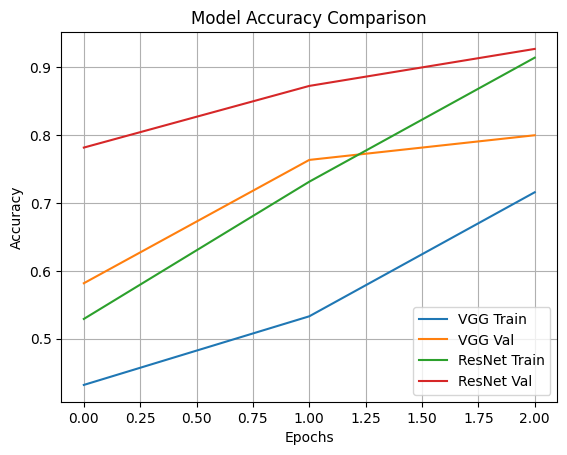

In [22]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.plot(train_accs, label='VGG Train')
plt.plot(val_accs, label='VGG Val')

plt.plot(resnet_train_accs, label='ResNet Train')
plt.plot(resnet_val_accs, label='ResNet Val')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

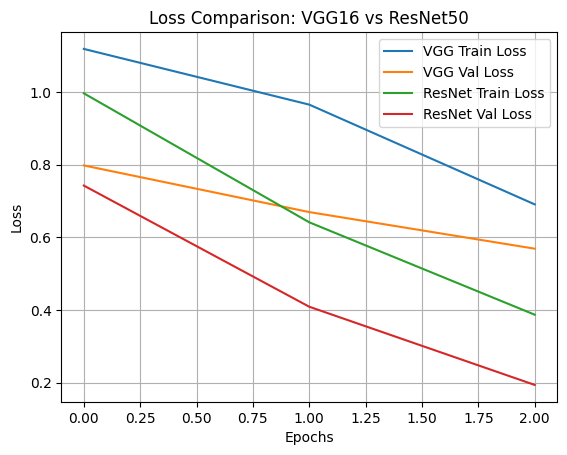

In [23]:
import matplotlib.pyplot as plt

plt.figure()

# VGG Loss
plt.plot(train_losses, label='VGG Train Loss')
plt.plot(val_losses, label='VGG Val Loss')

# ResNet Loss
plt.plot(resnet_train_losses, label='ResNet Train Loss')
plt.plot(resnet_val_losses, label='ResNet Val Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison: VGG16 vs ResNet50")
plt.legend()
plt.grid(True)

plt.show()

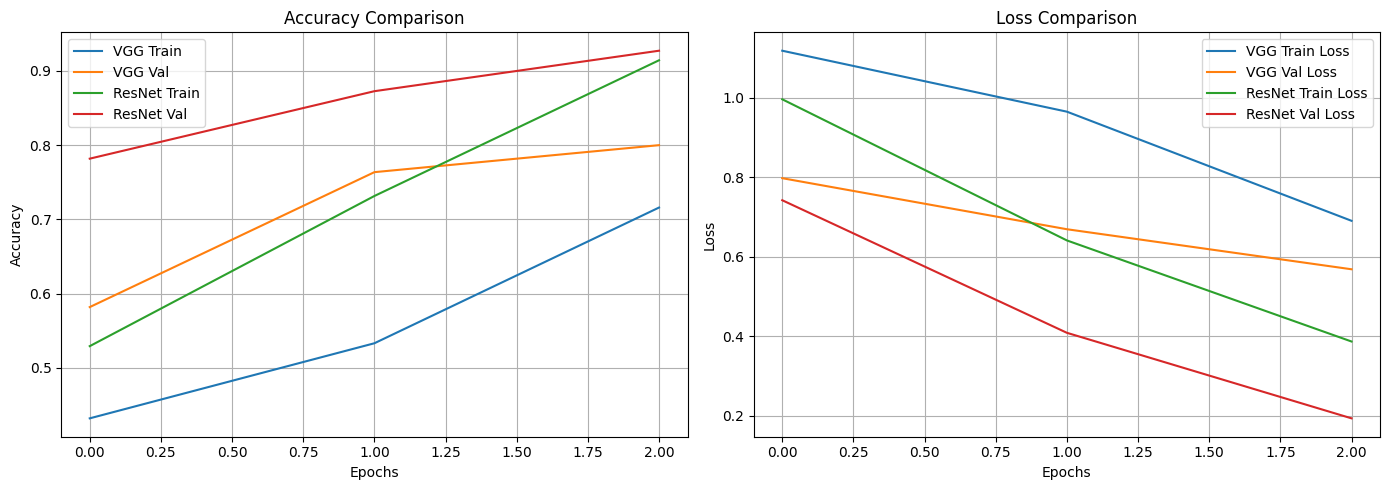

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ================= LEFT: ACCURACY =================
axes[0].plot(train_accs, label='VGG Train')
axes[0].plot(val_accs, label='VGG Val')

axes[0].plot(resnet_train_accs, label='ResNet Train')
axes[0].plot(resnet_val_accs, label='ResNet Val')

axes[0].set_title("Accuracy Comparison")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# ================= RIGHT: LOSS =================
axes[1].plot(train_losses, label='VGG Train Loss')
axes[1].plot(val_losses, label='VGG Val Loss')

axes[1].plot(resnet_train_losses, label='ResNet Train Loss')
axes[1].plot(resnet_val_losses, label='ResNet Val Loss')

axes[1].set_title("Loss Comparison")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report

print("\nVGG16 Classification Report:")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=train_data.classes))

print("\nResNet50 Classification Report:")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=train_data.classes))


VGG16 Classification Report:
              precision    recall  f1-score   support

  algal_leaf       1.00      0.76      0.87        17
brown_blight       0.65      1.00      0.79        17
  white_spot       0.82      0.64      0.72        22

    accuracy                           0.79        56
   macro avg       0.83      0.80      0.79        56
weighted avg       0.83      0.79      0.79        56


ResNet50 Classification Report:
              precision    recall  f1-score   support

  algal_leaf       0.92      0.71      0.80        17
brown_blight       0.93      0.82      0.88        17
  white_spot       0.71      0.91      0.80        22

    accuracy                           0.82        56
   macro avg       0.86      0.81      0.83        56
weighted avg       0.84      0.82      0.82        56



Confusion matrices

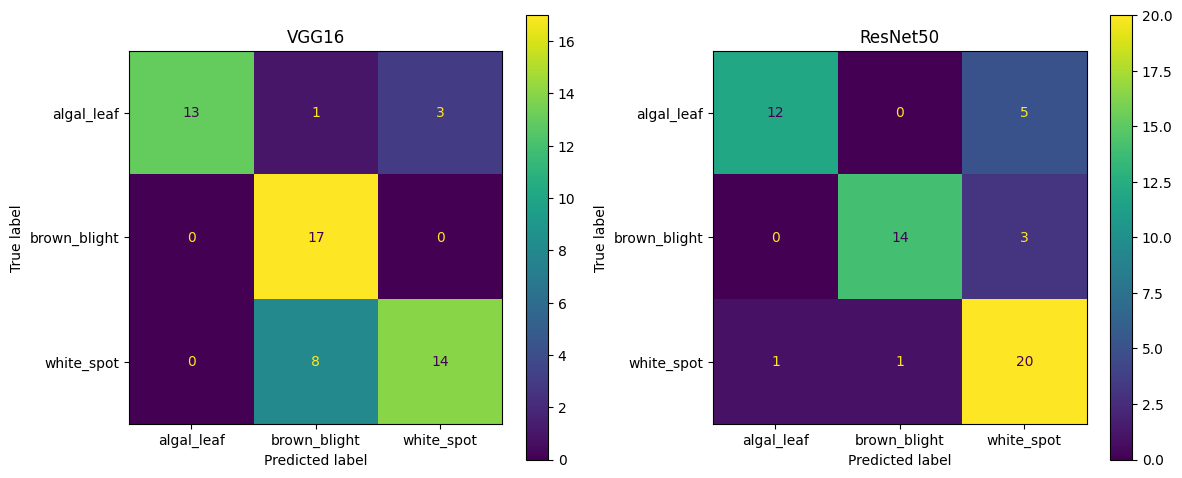

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Class names
class_names = train_data.classes

# Compute confusion matrices
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 VGG16
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_names)
disp_vgg.plot(ax=axes[0])
axes[0].set_title("VGG16")

# 🔹 ResNet50
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_names)
disp_resnet.plot(ax=axes[1])
axes[1].set_title("ResNet50")

plt.tight_layout()
plt.show()
for ax in axes:
    ax.grid(False)

In [27]:
best_model = "ResNet50" if resnet_test_acc > vgg_test_acc else "VGG16"
print(f"\n Best Model: {best_model}")


 Best Model: ResNet50


Classification

In [28]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification reports as dictionaries
vgg_report = classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=train_data.classes,
    output_dict=True
)

resnet_report = classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=train_data.classes,
    output_dict=True
)

# Convert to DataFrames
vgg_df = pd.DataFrame(vgg_report).transpose()
resnet_df = pd.DataFrame(resnet_report).transpose()

# Rename columns to distinguish models
vgg_df = vgg_df.add_prefix("VGG16_")
resnet_df = resnet_df.add_prefix("ResNet50_")


comparison_df = pd.concat([vgg_df, resnet_df], axis=1)

comparison_df

,VGG16_precision,VGG16_recall,VGG16_f1-score,VGG16_support,ResNet50_precision,ResNet50_recall,ResNet50_f1-score,ResNet50_support
algal_leaf,1.000000,0.764706,0.866667,17.000000,0.923077,0.705882,0.800000,17.000000
brown_blight,0.653846,1.000000,0.790698,17.000000,0.933333,0.823529,0.875000,17.000000
white_spot,0.823529,0.636364,0.717949,22.000000,0.714286,0.909091,0.800000,22.000000
accuracy,0.785714,0.785714,0.785714,0.785714,0.821429,0.821429,0.821429,0.821429
macro avg,0.825792,0.800357,0.791771,56.000000,0.856899,0.812834,0.825000,56.000000
weighted avg,0.825590,0.785714,0.785180,56.000000,0.844165,0.821429,0.822768,56.000000


Predit a sample image

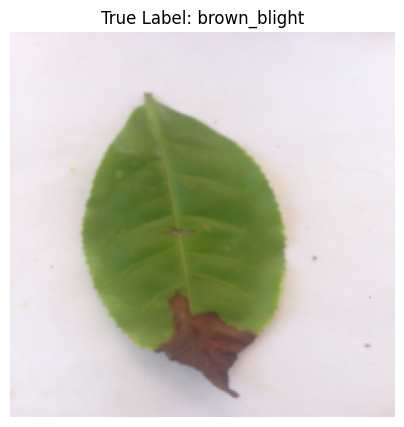

True Class: brown_blight
Predicted Class: brown_blight
Confidence: 0.9443


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ===============================
# 🔹 STEP 1 — Get sample image from test dataset
# ===============================
img_tensor, true_label_idx = test_data[25]

class_names = train_data.classes

# ===============================
# 🔹 STEP 2 — Unnormalize for display
# ===============================
img_display = img_tensor.clone().cpu().numpy().transpose((1, 2, 0))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

# ===============================
# 🔹 STEP 3 — Show image
# ===============================
plt.figure(figsize=(5,5))
plt.imshow(img_display)
plt.title(f"True Label: {class_names[true_label_idx]}")
plt.axis('off')
plt.show()

# ===============================
# 🔹 STEP 4 — Prepare for model
# ===============================
input_image = img_tensor.unsqueeze(0).to(device)

# Choose model (best one)
model = resnet   # or vgg

model.eval()

# ===============================
# 🔹 STEP 5 — Predict
# ===============================
with torch.no_grad():
    outputs = model(input_image)
    probabilities = torch.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

predicted_idx = predicted.item()
predicted_class = class_names[predicted_idx]
confidence = probabilities[0, predicted_idx].item()

# ===============================
# 🔹 STEP 6 — Print results
# ===============================
print(f"True Class: {class_names[true_label_idx]}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")